# 10 — Robustness, Fairness, and Extensions

Family importance, within-family HP importance (decomposition and V_m-based), and their seed aggregates are maintained in **notebook 06** (`thesis_outputs/tables/nb06/`, `figures/nb06/`).

This notebook covers:

1. **Rule feature frequency** across seeds (from notebook 09 outputs)
2. **Margin vs variance** — are hotspots simply near the decision boundary?
3. **Fairness / subgroup exposure** — are HH/HV regions overrepresented for sensitive groups (COMPAS)?
4. **Alternative kNN graph** — PCA-reduced and cosine-distance graphs
5. **Within-hotspot performance**, cross-family overlap, and related robustness checks below


In [1]:
import sys, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Robust project-root detection whether launched from repo root or notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (ROOT / "analysis").exists():
    if (Path.cwd() / "analysis").exists():
        ROOT = Path.cwd()
    elif (Path.cwd().parent / "analysis").exists():
        ROOT = Path.cwd().parent

for p in [str(ROOT), str(ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from analysis.run_analysis import (
    load_meta, load_P_test, load_split,
    select_rashomon_global,
    select_rashomon_per_family_totalK,
    pointwise_variance, spatial_analysis, run_spatial,
)
from analysis.preprocessing import get_transformed_test_features
from analysis.knn_defaults import K_NN_BY_DATASET
from data import load_dataset, make_preprocessor
from thesis_layout import RAW_RESULTS, resolve_csv, thesis_figure_dir, thesis_table_dir

RESULTS = RAW_RESULTS
TABLES = thesis_table_dir("nb10")
FIGURES = thesis_figure_dir("nb10")

K = 25
SEEDS = list(range(10))
DATASETS = ["compas", "german", "adult"]

print(f"ROOT={ROOT}")
_k_str = ", ".join(f"{d}:{K_NN_BY_DATASET[d]}" for d in DATASETS)
print(f"K={K}, k_nn by dataset ({_k_str}), seeds={SEEDS}, datasets={DATASETS}")

ROOT=c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity
K=25, k_nn by dataset (compas:30, german:30, adult:60), seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], datasets=['compas', 'german', 'adult']


## 1. Rule feature frequency across seeds

In [2]:
# Read existing rule stability tables (generated by notebook 09)
rule_tables = {}
for ds in DATASETS:
    path = resolve_csv(f"rule_stability_{ds}.csv", "nb09")
    if path is not None:
        rule_tables[ds] = pd.read_csv(path)
        print(f"{ds}: {len(rule_tables[ds])} rule stability rows")
    else:
        print(f"{ds}: no rule_stability table found")

compas: no rule_stability table found
german: no rule_stability table found
adult: no rule_stability table found


In [3]:
# Also check rule_feature_stability if it exists
feat_stab_path = resolve_csv("rule_feature_stability_compas.csv", "nb09")
if feat_stab_path is not None:
    df_feat_stab = pd.read_csv(feat_stab_path)
    print("Existing rule_feature_stability_compas.csv:")
    display(df_feat_stab.head(10))
else:
    print("No pre-existing feature stability table; will extract from rules.")

No pre-existing feature stability table; will extract from rules.


In [4]:
# Extract top features from rules across seeds
# Read rules_summary tables and parse feature names from rule strings
import re

def extract_features_from_rules(rules_df, feature_col="rule"):
    """Extract feature names mentioned in rule strings."""
    all_feats = []
    if feature_col not in rules_df.columns:
        for col in ["rule_text", "rule_string", "description"]:
            if col in rules_df.columns:
                feature_col = col
                break
        else:
            return pd.Series(dtype=float)
    
    for rule_str in rules_df[feature_col].dropna():
        # Match patterns like "feature_name <= X" or "feature_name > X"
        feats = re.findall(r'([a-zA-Z_][a-zA-Z0-9_]*(?:__[a-zA-Z0-9_]+)*)\s*[<>=!]+', str(rule_str))
        all_feats.extend(feats)
    
    if not all_feats:
        return pd.Series(dtype=float)
    return pd.Series(all_feats).value_counts()

for ds in DATASETS:
    path = resolve_csv(f"rules_summary_{ds}.csv", "nb09")
    if path is not None:
        rules_df = pd.read_csv(path)
        print(f"\n=== {ds} ===")
        print(f"Columns: {list(rules_df.columns)}")
        freq = extract_features_from_rules(rules_df)
        if len(freq):
            print(f"Top features in rules:")
            print(freq.head(10))
        else:
            print("Could not parse features from rule strings.")
    else:
        print(f"No rules_summary for {ds}")

No rules_summary for compas
No rules_summary for german
No rules_summary for adult


In [5]:
# More robust approach: read the final_rules tables
for ds in ["compas"]:
    path = resolve_csv(f"final_rules_{ds}.csv", "nb09")
    if path is not None:
        final_rules = pd.read_csv(path)
        print(f"final_rules_{ds}.csv columns: {list(final_rules.columns)}")
        display(final_rules.head(10))

In [6]:
# Aggregate rule feature frequency across all rule tables
# Approach: for each dataset, look for columns that contain feature names

feature_freq_all = {}

for ds in DATASETS:
    all_feats = []
    for tbl_name in [f"rules_summary_{ds}.csv", f"final_rules_{ds}.csv"]:
        path = resolve_csv(tbl_name, "nb09")
        if path is None:
            continue
        df = pd.read_csv(path)
        # Try to extract features from any text column that might contain rules
        for col in df.columns:
            if df[col].dtype == object:
                for val in df[col].dropna():
                    feats = re.findall(
                        r'([a-zA-Z_][a-zA-Z0-9_]*(?:__[a-zA-Z0-9_]+)*)\s*[<>=!]+',
                        str(val)
                    )
                    all_feats.extend(feats)
    
    if all_feats:
        freq = pd.Series(all_feats).value_counts()
        feature_freq_all[ds] = freq
        print(f"\n{ds} — Top 10 features in rules:")
        print(freq.head(10))
    else:
        print(f"\n{ds} — No features extracted")

# Save feature frequency table for COMPAS
if "compas" in feature_freq_all:
    freq_df = feature_freq_all["compas"].reset_index()
    freq_df.columns = ["feature", "frequency"]
    freq_df.to_csv(TABLES / "rule_feature_frequency_compas.csv", index=False)
    print("\nSaved rule_feature_frequency_compas.csv")


compas — No features extracted

german — No features extracted

adult — No features extracted


---
## 2. Decision Boundary Analysis: Variance vs Margin

Test if HH/HV points are simply those near `p_mean = 0.5` (low margin).

In [7]:
margin_rows = []

for dataset in DATASETS:
    for seed in SEEDS:
        run_dir = RESULTS / dataset / f"seed={seed}"
        try:
            P_test = load_P_test(run_dir)
            idx_global = select_rashomon_global(run_dir, K=K)
            P_sel = P_test[idx_global]
            
            p_mean = P_sel.mean(axis=0)
            margin = np.abs(p_mean - 0.5)
            v = pointwise_variance(P_sel)
            
            # HV: top 10% by variance
            q90 = np.quantile(v, 0.90)
            hv_mask = v >= q90
            
            # HH from spatial analysis
            X_test = get_transformed_test_features(run_dir, dataset)
            sp = spatial_analysis(v, X_test, k=K_NN_BY_DATASET[dataset], permutations=999)
            hh_mask = sp["HH_mask"]
            
            # Correlations
            r_pearson, p_pearson = stats.pearsonr(v, margin)
            r_spearman, p_spearman = stats.spearmanr(v, margin)
            
            margin_rows.append({
                "dataset": dataset,
                "seed": seed,
                "pearson_r": r_pearson,
                "pearson_p": p_pearson,
                "spearman_r": r_spearman,
                "spearman_p": p_spearman,
                "margin_mean_hh": margin[hh_mask].mean() if hh_mask.sum() > 0 else np.nan,
                "margin_mean_non_hh": margin[~hh_mask].mean(),
                "margin_mean_hv": margin[hv_mask].mean(),
                "margin_mean_non_hv": margin[~hv_mask].mean(),
                "n_hh": int(hh_mask.sum()),
                "n_hv": int(hv_mask.sum()),
                "n_test": len(v),
            })
        except Exception as e:
            print(f"  {dataset} seed={seed}: SKIP ({e})")

df_margin = pd.DataFrame(margin_rows)
print(f"Collected {len(df_margin)} margin analysis rows")

Collected 30 margin analysis rows


In [8]:
# Summary table: correlation between variance and margin
agg_margin = df_margin.groupby("dataset").agg(
    pearson_r_mean=("pearson_r", "mean"),
    pearson_r_std=("pearson_r", "std"),
    spearman_r_mean=("spearman_r", "mean"),
    spearman_r_std=("spearman_r", "std"),
    margin_hh_mean=("margin_mean_hh", lambda x: x.dropna().mean()),
    margin_hh_std=("margin_mean_hh", lambda x: x.dropna().std()),
    margin_non_hh_mean=("margin_mean_non_hh", "mean"),
    margin_non_hh_std=("margin_mean_non_hh", "std"),
    margin_hv_mean=("margin_mean_hv", "mean"),
    margin_non_hv_mean=("margin_mean_non_hv", "mean"),
).reset_index()

print("Variance vs Margin correlation (aggregated):")
display(agg_margin)

agg_margin.to_csv(TABLES / "variance_vs_margin_summary.csv", index=False)

Variance vs Margin correlation (aggregated):


,dataset,pearson_r_mean,pearson_r_std,spearman_r_mean,spearman_r_std,margin_hh_mean,margin_hh_std,margin_non_hh_mean,margin_non_hh_std,margin_hv_mean,margin_non_hv_mean
0,adult,-0.331674,0.039044,-0.888616,0.017555,0.224711,0.019862,0.374689,0.002872,0.196331,0.389509
1,compas,-0.043352,0.091062,-0.074199,0.175108,0.193723,0.041370,0.177802,0.005368,0.172169,0.178242
2,german,-0.556165,0.131852,-0.695409,0.103495,0.155026,0.060514,0.257400,0.017834,0.135761,0.269457


In [9]:
# Wilcoxon rank-sum test: margin for HH vs non-HH (per dataset)
wilcoxon_rows = []

for dataset in DATASETS:
    for seed in SEEDS:
        run_dir = RESULTS / dataset / f"seed={seed}"
        try:
            P_test = load_P_test(run_dir)
            idx = select_rashomon_global(run_dir, K=K)
            P_sel = P_test[idx]
            p_mean = P_sel.mean(axis=0)
            margin = np.abs(p_mean - 0.5)
            v = pointwise_variance(P_sel)
            
            X_test = get_transformed_test_features(run_dir, dataset)
            sp = spatial_analysis(v, X_test, k=K_NN_BY_DATASET[dataset], permutations=999)
            hh_mask = sp["HH_mask"]
            
            if hh_mask.sum() >= 3 and (~hh_mask).sum() >= 3:
                stat, pval = stats.mannwhitneyu(
                    margin[hh_mask], margin[~hh_mask], alternative="less"
                )
                wilcoxon_rows.append({
                    "dataset": dataset, "seed": seed,
                    "U_stat": stat, "p_value": pval,
                    "margin_hh": margin[hh_mask].mean(),
                    "margin_non_hh": margin[~hh_mask].mean(),
                })
        except Exception:
            pass

df_wilcoxon = pd.DataFrame(wilcoxon_rows)
if len(df_wilcoxon):
    agg_w = df_wilcoxon.groupby("dataset").agg(
        mean_pval=("p_value", "mean"),
        frac_sig=("p_value", lambda x: (x < 0.05).mean()),
        margin_hh=("margin_hh", "mean"),
        margin_non_hh=("margin_non_hh", "mean"),
    ).reset_index()
    print("Mann-Whitney U: margin(HH) < margin(non-HH)?")
    display(agg_w)
    agg_w.to_csv(TABLES / "margin_hh_wilcoxon.csv", index=False)

Mann-Whitney U: margin(HH) < margin(non-HH)?


,dataset,mean_pval,frac_sig,margin_hh,margin_non_hh
0,adult,3.502162e-22,1.000000,0.224711,0.374689
1,compas,5.883306e-01,0.300000,0.193723,0.177802
2,german,1.477805e-01,0.571429,0.155026,0.256291


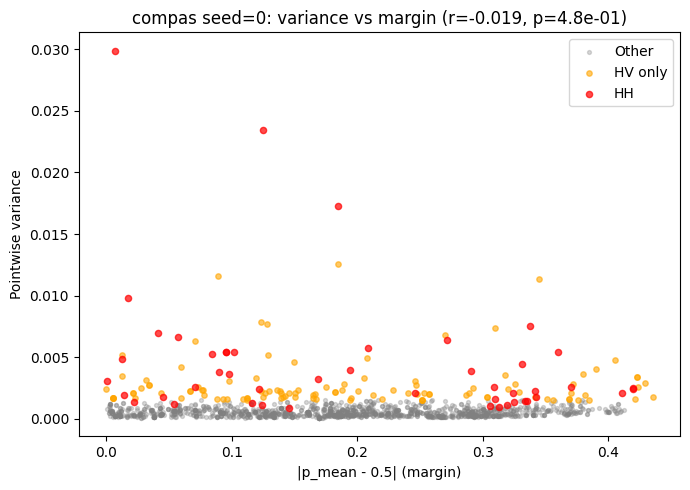

In [10]:
# Scatter plot: variance vs margin for COMPAS seed=0
ds_plot = "compas"
seed_plot = 0
run_dir = RESULTS / ds_plot / f"seed={seed_plot}"

P_test = load_P_test(run_dir)
idx = select_rashomon_global(run_dir, K=K)
P_sel = P_test[idx]
p_mean = P_sel.mean(axis=0)
margin = np.abs(p_mean - 0.5)
v = pointwise_variance(P_sel)

X_test = get_transformed_test_features(run_dir, ds_plot)
sp = spatial_analysis(v, X_test, k=K_NN_BY_DATASET[ds_plot], permutations=999)
hh_mask = sp["HH_mask"]
q90 = np.quantile(v, 0.90)
hv_mask = v >= q90

fig, ax = plt.subplots(figsize=(7, 5))
# Non-hotspot
other = ~hh_mask & ~hv_mask
ax.scatter(margin[other], v[other], s=8, alpha=0.3, c="gray", label="Other")
# HV only
hv_only = hv_mask & ~hh_mask
ax.scatter(margin[hv_only], v[hv_only], s=15, alpha=0.6, c="orange", label="HV only")
# HH
ax.scatter(margin[hh_mask], v[hh_mask], s=20, alpha=0.7, c="red", label="HH")

r, p = stats.pearsonr(v, margin)
ax.set_xlabel("|p_mean - 0.5| (margin)")
ax.set_ylabel("Pointwise variance")
ax.set_title(f"{ds_plot} seed={seed_plot}: variance vs margin (r={r:.3f}, p={p:.1e})")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / f"variance_vs_margin_{ds_plot}.pdf", bbox_inches="tight")
plt.show()

---
## 3. Fairness / Subgroup Exposure (COMPAS)

Are HH/HV regions overrepresented for sensitive groups (race, sex)?

In [11]:
X_raw, y_raw, feature_info = load_dataset("compas")
print(f"COMPAS features: {list(X_raw.columns)}")
print(f"Race values: {X_raw['race'].value_counts().to_dict()}")
print(f"Sex values: {X_raw['sex'].value_counts().to_dict()}")

COMPAS features: ['age', 'priors_count', 'sex', 'race', 'c_charge_degree']
Race values: {'African-American': 3696, 'Caucasian': 2454, 'Hispanic': 637, 'Other': 377, 'Asian': 32, 'Native American': 18}
Sex values: {'Male': 5819, 'Female': 1395}


In [12]:
fairness_rows = []
_fairness_cache = {}  # {seed: (hh_mask, X_test_raw_df)} for reuse in permutation tests
MIN_GROUP_N = 30      # Minimum per-seed subgroup size for significance reporting

for seed in SEEDS:
    run_dir = RESULTS / "compas" / f"seed={seed}"
    try:
        split = load_split(run_dir)
        test_idx = split["test"]
        X_test_raw_i = X_raw.iloc[test_idx]

        P_test = load_P_test(run_dir)
        idx = select_rashomon_global(run_dir, K=K)
        P_sel = P_test[idx]
        v = pointwise_variance(P_sel)

        # HV: top 10%
        q90 = np.quantile(v, 0.90)
        hv_mask = v >= q90

        # HH from spatial analysis
        X_test_proc = get_transformed_test_features(run_dir, "compas")
        sp = spatial_analysis(v, X_test_proc, k=K_NN_BY_DATASET["compas"], permutations=999)
        hh_mask = sp["HH_mask"]

        _fairness_cache[seed] = (hh_mask, X_test_raw_i)

        for group_col in ["race", "sex"]:
            group_vals = X_test_raw_i[group_col].values
            for g in np.unique(group_vals):
                g_mask = group_vals == g
                n_group = int(g_mask.sum())
                fairness_rows.append({
                    "seed": seed,
                    "group_col": group_col,
                    "group_val": g,
                    "n_group": n_group,
                    "n_test": len(v),
                    "eligible_sig": n_group >= MIN_GROUP_N,
                    "hh_rate": hh_mask[g_mask].mean() if n_group > 0 else np.nan,
                    "hv_rate": hv_mask[g_mask].mean() if n_group > 0 else np.nan,
                    "mean_variance": v[g_mask].mean() if n_group > 0 else np.nan,
                })
    except Exception as e:
        print(f"  seed={seed}: SKIP ({e})")

df_fair = pd.DataFrame(fairness_rows)
print(f"Collected {len(df_fair)} fairness rows")
print(f"Significance threshold: min subgroup size per seed = {MIN_GROUP_N}")

Collected 80 fairness rows
Significance threshold: min subgroup size per seed = 30


In [13]:
# Aggregate: mean ± std across seeds per group
agg_fair = df_fair.groupby(["group_col", "group_val"]).agg(
    hh_rate_mean=("hh_rate", "mean"),
    hh_rate_std=("hh_rate", "std"),
    hv_rate_mean=("hv_rate", "mean"),
    hv_rate_std=("hv_rate", "std"),
    mean_var_mean=("mean_variance", "mean"),
    mean_var_std=("mean_variance", "std"),
    n_seeds=("seed", "count"),
    n_seed_eligible=("eligible_sig", "sum"),
    n_group_mean=("n_group", "mean"),
).reset_index()


def _bootstrap_mean_ci(values, n_boot=2000, seed=42):
    """Bootstrap CI for the mean from per-seed subgroup rates."""
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan
    if len(arr) == 1:
        return float(arr[0]), float(arr[0])
    rng = np.random.RandomState(seed)
    boot = rng.choice(arr, size=(n_boot, len(arr)), replace=True).mean(axis=1)
    return float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))


ci_rows = []
for (group_col, group_val), sub in df_fair.groupby(["group_col", "group_val"]):
    hh_ci_low, hh_ci_high = _bootstrap_mean_ci(sub["hh_rate"].values)
    hv_ci_low, hv_ci_high = _bootstrap_mean_ci(sub["hv_rate"].values)
    ci_rows.append({
        "group_col": group_col,
        "group_val": group_val,
        "hh_rate_ci_low": hh_ci_low,
        "hh_rate_ci_high": hh_ci_high,
        "hv_rate_ci_low": hv_ci_low,
        "hv_rate_ci_high": hv_ci_high,
    })

ci_df = pd.DataFrame(ci_rows)
agg_fair = agg_fair.merge(ci_df, on=["group_col", "group_val"], how="left")
agg_fair = agg_fair.sort_values(["group_col", "hh_rate_mean"], ascending=[True, False]).reset_index(drop=True)

print("COMPAS: Group-wise HH/HV rates (mean ± std across seeds):")
print(f"Eligibility threshold for significance reporting: n_group >= {MIN_GROUP_N} per seed")
display(agg_fair)

agg_fair.to_csv(TABLES / "fairness_subgroup_rates_compas.csv", index=False)

COMPAS: Group-wise HH/HV rates (mean ± std across seeds):
Eligibility threshold for significance reporting: n_group >= 30 per seed


,group_col,group_val,hh_rate_mean,hh_rate_std,hv_rate_mean,hv_rate_std,mean_var_mean,mean_var_std,n_seeds,n_seed_eligible,n_group_mean,hh_rate_ci_low,hh_rate_ci_high,hv_rate_ci_low,hv_rate_ci_high
0,race,Native American,0.189286,0.309750,0.723810,0.278616,0.003647,0.001695,10,0,3.8,0.041667,0.391667,0.547619,0.890476
1,race,Asian,0.162024,0.215710,0.652143,0.251752,0.004371,0.002060,10,0,6.4,0.053571,0.294286,0.499286,0.796429
2,race,Other,0.115430,0.128224,0.210050,0.089448,0.001937,0.000477,10,10,71.3,0.055686,0.195314,0.156559,0.262982
3,race,African-American,0.079518,0.058010,0.103178,0.015607,0.001308,0.000371,10,10,728.9,0.045785,0.112547,0.093588,0.112236
4,race,Caucasian,0.031758,0.017795,0.073346,0.013012,0.001177,0.000246,10,10,504.5,0.022220,0.042809,0.065821,0.080774
5,race,Hispanic,0.021755,0.025948,0.090751,0.031710,0.001249,0.000348,10,10,128.1,0.009095,0.038307,0.071647,0.108154
6,sex,Male,0.060104,0.036454,0.094601,0.007138,0.001277,0.000307,10,10,1164.0,0.038883,0.080713,0.090602,0.099172
7,sex,Female,0.059954,0.060589,0.127133,0.030277,0.001444,0.000341,10,10,279.0,0.027144,0.095312,0.108253,0.144052


In [14]:
# Stratified permutation test for subgroup disparity in HH exposure.
# Recommended reporting: minimum group size threshold + pooled (across-seed) inference.
perm_rows = []
N_PERM = 2000
MIN_SEEDS_PER_GROUP = 5
rng = np.random.RandomState(42)


def _seed_group_rates(hh_mask, group_vals, min_group_n):
    """Per-seed HH rates for groups with enough support."""
    rates = {}
    groups, counts = np.unique(group_vals, return_counts=True)
    for g, n in zip(groups, counts):
        if n >= min_group_n:
            g_mask = group_vals == g
            rates[g] = float(hh_mask[g_mask].mean())
    return rates


def _aggregate_group_means(per_seed_rates, min_seeds_per_group):
    """Aggregate group HH rates across seeds; keep groups observed in enough seeds."""
    group_to_vals = {}
    for rates in per_seed_rates.values():
        for g, v in rates.items():
            group_to_vals.setdefault(g, []).append(v)
    return {
        g: float(np.mean(vs))
        for g, vs in group_to_vals.items()
        if len(vs) >= min_seeds_per_group
    }


for group_col in ["race", "sex"]:
    # Observed rates by seed
    per_seed_rates = {}
    for seed in SEEDS:
        if seed not in _fairness_cache:
            continue
        hh_mask, X_test_raw_i = _fairness_cache[seed]
        group_vals = X_test_raw_i[group_col].values
        per_seed_rates[seed] = _seed_group_rates(hh_mask, group_vals, MIN_GROUP_N)

    obs_group_means = _aggregate_group_means(per_seed_rates, MIN_SEEDS_PER_GROUP)
    if len(obs_group_means) < 2:
        print(f"  {group_col}: SKIP (fewer than 2 eligible groups)")
        continue

    obs_range = max(obs_group_means.values()) - min(obs_group_means.values())

    # Null distribution via within-seed label shuffling (stratified by seed)
    null_ranges = []
    for _ in range(N_PERM):
        perm_seed_rates = {}
        for seed in per_seed_rates.keys():
            hh_mask, X_test_raw_i = _fairness_cache[seed]
            shuffled_vals = rng.permutation(X_test_raw_i[group_col].values)
            perm_seed_rates[seed] = _seed_group_rates(hh_mask, shuffled_vals, MIN_GROUP_N)

        perm_group_means = _aggregate_group_means(perm_seed_rates, MIN_SEEDS_PER_GROUP)
        if len(perm_group_means) >= 2:
            null_ranges.append(max(perm_group_means.values()) - min(perm_group_means.values()))

    null_ranges = np.asarray(null_ranges, dtype=float)
    p_val = (1 + (null_ranges >= obs_range).sum()) / (len(null_ranges) + 1)

    perm_rows.append({
        "group_col": group_col,
        "obs_range_stratified": float(obs_range),
        "null_range_mean": float(null_ranges.mean()) if len(null_ranges) else np.nan,
        "null_range_std": float(null_ranges.std()) if len(null_ranges) else np.nan,
        "null_ci_low": float(np.quantile(null_ranges, 0.025)) if len(null_ranges) else np.nan,
        "null_ci_high": float(np.quantile(null_ranges, 0.975)) if len(null_ranges) else np.nan,
        "p_value_stratified": float(p_val),
        "n_perm_valid": int(len(null_ranges)),
        "n_groups_eligible": int(len(obs_group_means)),
        "eligible_groups": ", ".join(sorted(obs_group_means.keys())),
        "min_group_n": int(MIN_GROUP_N),
        "min_seeds_per_group": int(MIN_SEEDS_PER_GROUP),
        # Compatibility columns for older table readers
        "mean_p": float(p_val),
        "obs_range_mean": float(obs_range),
    })

df_perm = pd.DataFrame(perm_rows)
print("Stratified permutation test: is HH-rate disparity larger than expected by chance?")
display(df_perm)
df_perm.to_csv(TABLES / "fairness_permutation_test_compas.csv", index=False)

Stratified permutation test: is HH-rate disparity larger than expected by chance?


,group_col,obs_range_stratified,null_range_mean,null_range_std,null_ci_low,null_ci_high,p_value_stratified,n_perm_valid,n_groups_eligible,eligible_groups,min_group_n,min_seeds_per_group,mean_p,obs_range_mean
0,race,0.093675,0.011941,0.005931,0.002788,0.025528,0.00050,2000,4,"African-American, Caucasian, Hispanic, Other",30,5,0.00050,0.093675
1,sex,0.000150,0.003957,0.002981,0.000169,0.011062,0.97901,2000,2,"Female, Male",30,5,0.97901,0.000150


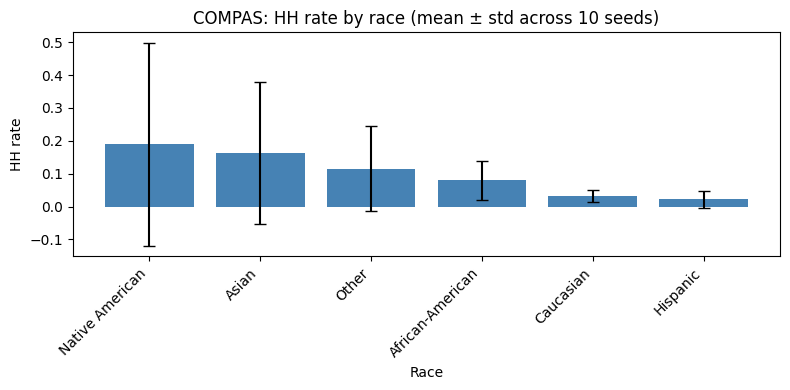

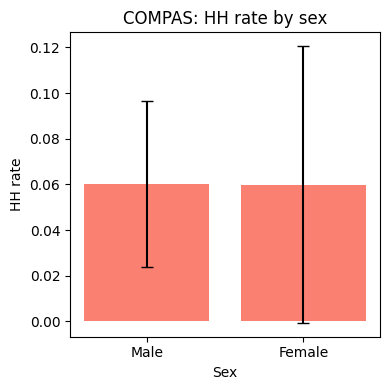

In [15]:
# Bar chart: HH rate by race (with error bars)
race_data = agg_fair[agg_fair["group_col"] == "race"].copy()
race_data = race_data.sort_values("hh_rate_mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(race_data["group_val"], race_data["hh_rate_mean"],
       yerr=race_data["hh_rate_std"], capsize=4, color="steelblue")
ax.set_ylabel("HH rate")
ax.set_xlabel("Race")
ax.set_title("COMPAS: HH rate by race (mean ± std across 10 seeds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "fairness_hh_rate_by_race_compas.pdf", bbox_inches="tight")
plt.show()

# Sex
sex_data = agg_fair[agg_fair["group_col"] == "sex"].copy()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(sex_data["group_val"], sex_data["hh_rate_mean"],
       yerr=sex_data["hh_rate_std"], capsize=4, color="salmon")
ax.set_ylabel("HH rate")
ax.set_xlabel("Sex")
ax.set_title("COMPAS: HH rate by sex")
plt.tight_layout()
fig.savefig(FIGURES / "fairness_hh_rate_by_sex_compas.pdf", bbox_inches="tight")
plt.show()

In [16]:
# Robustness check: kNN graph EXCLUDING protected attributes (race, sex)
# Column selection is derived from the fitted preprocessor's feature names per run.

from libpysal.weights import KNN as PySAL_KNN
from esda.moran import Moran, Moran_Local
from analysis.run_analysis import _fdr_benjamini_hochberg


def _get_non_protected_cols_for_run(run_dir):
    """Return preprocessed column indices that are NOT race/sex for this run."""
    X_compas, y_compas, fi_compas = load_dataset("compas")
    split = load_split(run_dir)
    pre = make_preprocessor(fi_compas, scale_numeric=True)
    pre.fit(X_compas.iloc[split["train"]], y_compas.iloc[split["train"]])
    feat_names = list(pre.get_feature_names_out())
    keep = [
        i for i, n in enumerate(feat_names)
        if ("cat__sex_" not in n and "cat__race_" not in n)
    ]
    return keep, feat_names


excl_rows = []
for seed in SEEDS:
    run_dir = RESULTS / "compas" / f"seed={seed}"
    try:
        P_test = load_P_test(run_dir)
        idx = select_rashomon_global(run_dir, K=K)
        P_sel = P_test[idx]
        v = pointwise_variance(P_sel)

        X_test_full = get_transformed_test_features(run_dir, "compas")
        if hasattr(X_test_full, "toarray"):
            X_test_full = X_test_full.toarray()
        X_test_full = np.asarray(X_test_full, dtype=float)

        non_prot_cols, feat_names = _get_non_protected_cols_for_run(run_dir)
        if X_test_full.shape[1] != len(feat_names):
            raise ValueError(
                f"Feature mismatch: transformed has {X_test_full.shape[1]} cols, "
                f"preprocessor reports {len(feat_names)}"
            )

        # Full graph (baseline)
        sp_full = spatial_analysis(v, X_test_full, k=K_NN_BY_DATASET["compas"], permutations=999)

        # Graph excluding protected attributes
        X_no_prot = X_test_full[:, non_prot_cols]
        W_np = PySAL_KNN.from_array(X_no_prot, k=K_NN_BY_DATASET["compas"])
        W_np.transform = "r"
        np.random.seed(42)
        moran_np = Moran(v, W_np, permutations=999)
        lm_np = Moran_Local(v, W_np, transformation="r", permutations=999, seed=42)
        p_sim_np = np.asarray(lm_np.p_sim).flatten()
        q_np = np.asarray(lm_np.q).flatten()
        sig_np = _fdr_benjamini_hochberg(p_sim_np, alpha=0.05)
        hh_np = (q_np == 1) & sig_np

        # Jaccard overlap
        hh_full = sp_full["HH_mask"]
        inter = np.logical_and(hh_full, hh_np).sum()
        union = np.logical_or(hh_full, hh_np).sum()
        jaccard = inter / union if union > 0 else 1.0

        excl_rows.append({
            "seed": seed,
            "moran_full": sp_full["moran_i"],
            "moran_excl_prot": float(moran_np.I),
            "n_hh_full": int(hh_full.sum()),
            "n_hh_excl_prot": int(hh_np.sum()),
            "jaccard_hh": jaccard,
        })
    except Exception as e:
        print(f"  seed={seed}: SKIP ({e})")


df_excl = pd.DataFrame(excl_rows)
print("kNN graph: full features vs. excluding race/sex (COMPAS)")
print(f"  Moran I   full: {df_excl['moran_full'].mean():.3f} +/- {df_excl['moran_full'].std():.3f}")
print(f"  Moran I   excl: {df_excl['moran_excl_prot'].mean():.3f} +/- {df_excl['moran_excl_prot'].std():.3f}")
print(f"  n_HH      full: {df_excl['n_hh_full'].mean():.1f} +/- {df_excl['n_hh_full'].std():.1f}")
print(f"  n_HH      excl: {df_excl['n_hh_excl_prot'].mean():.1f} +/- {df_excl['n_hh_excl_prot'].std():.1f}")
print(f"  Jaccard HH:     {df_excl['jaccard_hh'].mean():.3f} +/- {df_excl['jaccard_hh'].std():.3f}")
df_excl.to_csv(TABLES / "knn_excl_protected_compas.csv", index=False)

c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


kNN graph: full features vs. excluding race/sex (COMPAS)
  Moran I   full: 0.199 +/- 0.077
  Moran I   excl: 0.246 +/- 0.092
  n_HH      full: 86.7 +/- 55.0
  n_HH      excl: 119.6 +/- 69.6
  Jaccard HH:     0.479 +/- 0.130


---
## 4. Alternative kNN Graph Constructions

Test whether spatial results depend on the distance metric / representation.

In [17]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from libpysal.weights import KNN as PySAL_KNN
from libpysal.weights import W as PySAL_W
from esda.moran import Moran, Moran_Local


def build_cosine_knn_weights(X, k=30):
    """Build kNN graph using cosine distance, return PySAL weights."""
    X_norm = normalize(X, norm="l2")
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine", algorithm="brute")
    nn.fit(X_norm)
    distances, indices = nn.kneighbors(X_norm)
    
    neighbors = {}
    weights = {}
    for i in range(X.shape[0]):
        neighbors[i] = indices[i, 1:].tolist()  # exclude self -> k neighbors
        w = np.ones(k)
        w = w / w.sum()
        weights[i] = w.tolist()
    
    return PySAL_W(neighbors, weights)


def build_pca_knn_weights(X, n_components=15, k=30):
    """Build kNN graph in PCA-reduced space, return PySAL weights."""
    n_components = min(n_components, X.shape[1], X.shape[0])
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    W = PySAL_KNN.from_array(X_pca, k=k)
    W.transform = "r"
    return W


def spatial_with_custom_W(v, W, permutations=999, fdr_alpha=0.05, seed=42):
    """Compute Moran's I + LISA with a pre-built weights matrix."""
    if seed is not None:
        np.random.seed(seed)
    moran_g = Moran(v, W, permutations=permutations)
    lm = Moran_Local(v, W, transformation="r", permutations=permutations, seed=seed)
    
    p_sim = np.asarray(lm.p_sim).flatten()
    q = np.asarray(lm.q).flatten()
    
    from analysis.run_analysis import _fdr_benjamini_hochberg
    sig = _fdr_benjamini_hochberg(p_sim, alpha=fdr_alpha)
    hh_mask = (q == 1) & sig
    
    return {
        "moran_i": float(moran_g.I),
        "moran_p": float(moran_g.p_sim),
        "n_hh": int(hh_mask.sum()),
        "HH_mask": hh_mask,
    }

In [18]:
alt_rows = []

for dataset in DATASETS:
    for seed in SEEDS:
        run_dir = RESULTS / dataset / f"seed={seed}"
        try:
            P_test = load_P_test(run_dir)
            idx = select_rashomon_global(run_dir, K=K)
            P_sel = P_test[idx]
            v = pointwise_variance(P_sel)
            X_test = get_transformed_test_features(run_dir, dataset)
            k_ds = K_NN_BY_DATASET[dataset]
            
            # Baseline: Euclidean kNN
            sp_base = spatial_analysis(v, X_test, k=k_ds, permutations=999)
            alt_rows.append({
                "dataset": dataset, "seed": seed, "method": "euclidean",
                "moran_i": sp_base["moran_i"],
                "n_hh": int(sp_base["HH_mask"].sum()),
            })
            
            # PCA kNN (15 components)
            W_pca = build_pca_knn_weights(X_test, n_components=15, k=k_ds)
            sp_pca = spatial_with_custom_W(v, W_pca)
            alt_rows.append({
                "dataset": dataset, "seed": seed, "method": "pca_15",
                "moran_i": sp_pca["moran_i"],
                "n_hh": sp_pca["n_hh"],
            })
            
            # Cosine kNN
            W_cos = build_cosine_knn_weights(X_test, k=k_ds)
            sp_cos = spatial_with_custom_W(v, W_cos)
            alt_rows.append({
                "dataset": dataset, "seed": seed, "method": "cosine",
                "moran_i": sp_cos["moran_i"],
                "n_hh": sp_cos["n_hh"],
            })
            
            if seed == 0:
                print(f"  {dataset} seed={seed}: euc={sp_base['moran_i']:.3f}, "
                      f"pca={sp_pca['moran_i']:.3f}, cos={sp_cos['moran_i']:.3f}")
        except Exception as e:
            print(f"  {dataset} seed={seed}: SKIP ({e})")

df_alt = pd.DataFrame(alt_rows)
print(f"\nCollected {len(df_alt)} alternative graph rows")

  compas seed=0: euc=0.141, pca=0.141, cos=0.156
  german seed=0: euc=0.116, pca=0.110, cos=0.136
  adult seed=0: euc=0.047, pca=0.048, cos=0.055

Collected 90 alternative graph rows


In [19]:
# Summary table: mean ± std per method per dataset
agg_alt = df_alt.groupby(["dataset", "method"]).agg(
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    hh_mean=("n_hh", "mean"),
    hh_std=("n_hh", "std"),
    n_seeds=("seed", "count"),
).reset_index()

print("Alternative kNN graph comparison (mean ± std across seeds):")
display(agg_alt)

agg_alt.to_csv(TABLES / "alternative_knn_comparison.csv", index=False)

Alternative kNN graph comparison (mean ± std across seeds):


,dataset,method,moran_mean,moran_std,hh_mean,hh_std,n_seeds
0,adult,cosine,0.078863,0.021699,410.1,131.371779,10
1,adult,euclidean,0.070358,0.020314,286.1,125.533041,10
2,adult,pca_15,0.075246,0.021262,411.1,145.874718,10
3,compas,cosine,0.209978,0.082902,114.9,50.766240,10
4,compas,euclidean,0.199279,0.077227,86.7,55.001111,10
5,compas,pca_15,0.198016,0.075869,82.2,50.070617,10
6,german,cosine,0.112340,0.043308,6.2,4.779586,10
7,german,euclidean,0.104155,0.039695,2.7,2.213594,10
8,german,pca_15,0.098329,0.039897,3.0,2.211083,10


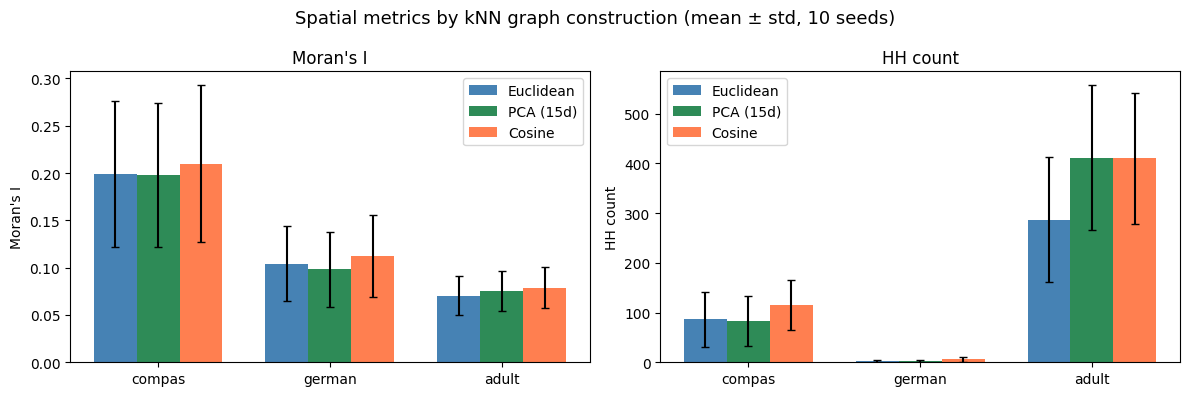

In [20]:
# Grouped bar plot: Moran's I by method for each dataset
methods = ["euclidean", "pca_15", "cosine"]
method_labels = ["Euclidean", "PCA (15d)", "Cosine"]
colors = ["steelblue", "seagreen", "coral"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_idx, metric in enumerate(["moran_i", "n_hh"]):
    ax = axes[ax_idx]
    x = np.arange(len(DATASETS))
    width = 0.25
    
    for i, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
        sub = agg_alt[agg_alt["method"] == method]
        means = []
        stds = []
        for ds in DATASETS:
            row = sub[sub["dataset"] == ds]
            if len(row):
                col_mean = "moran_mean" if metric == "moran_i" else "hh_mean"
                col_std = "moran_std" if metric == "moran_i" else "hh_std"
                means.append(row[col_mean].values[0])
                stds.append(row[col_std].values[0])
            else:
                means.append(0)
                stds.append(0)
        
        ax.bar(x + i * width, means, width, yerr=stds, label=label,
               color=color, capsize=3)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(DATASETS)
    ax.set_ylabel("Moran's I" if metric == "moran_i" else "HH count")
    ax.set_title("Moran's I" if metric == "moran_i" else "HH count")
    ax.legend()

fig.suptitle("Spatial metrics by kNN graph construction (mean ± std, 10 seeds)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "alternative_knn_comparison.pdf", bbox_inches="tight")
plt.show()

## 5. Within-Hotspot Performance

Compare accuracy and Brier score for HH (hotspot) vs non-HH points. If HH corresponds to higher error / higher uncertainty, it confirms that these regions are practically important.

In [21]:
from analysis.run_analysis import pointwise_conflict

perf_rows = []
for ds_name in DATASETS:
    ds_dir = RESULTS / ds_name
    X_full, y_full, _ = load_dataset(ds_name)

    for seed in SEEDS:
        run_dir = ds_dir / f"seed={seed}"
        if not run_dir.exists():
            continue

        P_test = load_P_test(run_dir)
        split = load_split(run_dir)
        idx = select_rashomon_global(run_dir, K=K)
        P_sel = P_test[idx]

        X_test = get_transformed_test_features(run_dir, ds_name)
        y_test = np.asarray(y_full.iloc[split["test"]].values, dtype=float)
        p_mean = P_sel.mean(axis=0)

        spatial_res = run_spatial(run_dir, X_test, K=K, k=K_NN_BY_DATASET[ds_name], seed=42)
        hh_mask = spatial_res["HH_mask"]

        for label, mask in [("HH", hh_mask), ("non-HH", ~hh_mask)]:
            if mask.sum() == 0:
                continue
            y_sub = y_test[mask]
            p_sub = p_mean[mask]
            pred_sub = (p_sub >= 0.5).astype(int)
            accuracy = float(np.mean(pred_sub == y_sub))
            brier = float(np.mean((p_sub - y_sub) ** 2))
            mean_var = float(pointwise_variance(P_sel[:, mask], ddof=0).mean())

            perf_rows.append({
                "dataset": ds_name,
                "seed": seed,
                "group": label,
                "n_points": int(mask.sum()),
                "accuracy": accuracy,
                "brier": brier,
                "mean_variance": mean_var,
            })

perf_df = pd.DataFrame(perf_rows)
agg_perf = perf_df.groupby(["dataset", "group"]).agg(
    n_points_mean=("n_points", "mean"),
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    brier_mean=("brier", "mean"),
    brier_std=("brier", "std"),
    mean_variance_mean=("mean_variance", "mean"),
    mean_variance_std=("mean_variance", "std"),
).reset_index()

print("Within-hotspot performance (mean ± std over seeds):\n")
for ds_name in DATASETS:
    ds_agg = agg_perf[agg_perf["dataset"] == ds_name]
    print(f"  {ds_name}:")
    for _, row in ds_agg.iterrows():
        print(f"    {row['group']:>7s}: accuracy={row['accuracy_mean']:.4f}±{row['accuracy_std']:.4f}, "
              f"brier={row['brier_mean']:.4f}±{row['brier_std']:.4f}, "
              f"mean_var={row['mean_variance_mean']:.6f}±{row['mean_variance_std']:.6f}, "
              f"n={row['n_points_mean']:.0f}")
    print()

display(agg_perf)
agg_perf.to_csv(TABLES / "hotspot_performance_comparison.csv", index=False)

Within-hotspot performance (mean ± std over seeds):

  compas:
         HH: accuracy=0.7122±0.0526, brier=0.1967±0.0301, mean_var=0.006006±0.003665, n=87
     non-HH: accuracy=0.6816±0.0096, brier=0.2080±0.0035, mean_var=0.001090±0.000244, n=1356

  german:
         HH: accuracy=0.6429±0.2794, brier=0.2138±0.0802, mean_var=0.011075±0.005218, n=4
     non-HH: accuracy=0.7587±0.0324, brier=0.1645±0.0150, mean_var=0.004940±0.002101, n=197

  adult:
         HH: accuracy=0.7378±0.0349, brier=0.1683±0.0183, mean_var=0.009203±0.002813, n=286
     non-HH: accuracy=0.8764±0.0034, brier=0.0861±0.0017, mean_var=0.001167±0.000104, n=9483



,dataset,group,n_points_mean,accuracy_mean,accuracy_std,brier_mean,brier_std,mean_variance_mean,mean_variance_std
0,adult,HH,286.100000,0.737837,0.034872,0.168333,0.018323,0.009203,0.002813
1,adult,non-HH,9482.900000,0.876426,0.003382,0.086145,0.001731,0.001167,0.000104
2,compas,HH,86.700000,0.712238,0.052587,0.196716,0.030064,0.006006,0.003665
3,compas,non-HH,1356.300000,0.681630,0.009585,0.208035,0.003478,0.001090,0.000244
4,german,HH,3.857143,0.642857,0.279361,0.213791,0.080246,0.011075,0.005218
5,german,non-HH,197.300000,0.758683,0.032355,0.164542,0.015023,0.004940,0.002101


## 6. Sensitivity to Conflict Decision Threshold

Conflict uses threshold τ=0.5 by default. Test robustness by computing conflict at τ ∈ {0.3, 0.5, 0.7} and checking whether conflict-HH regions overlap substantially across thresholds. Stable overlap supports conflict as a meaningful metric.

In [22]:
from analysis.run_analysis import pointwise_conflict, spatial_analysis, spatial_hh_jaccard
from analysis.stability import jaccard_index

TAU_VALUES = [0.3, 0.5, 0.7]

threshold_rows = []
for ds_name in DATASETS:
    ds_dir = RESULTS / ds_name
    for seed in SEEDS:
        run_dir = ds_dir / f"seed={seed}"
        if not run_dir.exists():
            continue

        P_test = load_P_test(run_dir)
        idx = select_rashomon_global(run_dir, K=K)
        P_sel = P_test[idx]
        X_test = get_transformed_test_features(run_dir, ds_name)

        hh_masks_by_tau = {}
        for tau in TAU_VALUES:
            c = pointwise_conflict(P_sel, tau=tau)
            if float(np.var(c)) < 1e-15:
                hh_masks_by_tau[tau] = np.zeros(len(c), dtype=bool)
                threshold_rows.append({
                    "dataset": ds_name, "seed": seed, "tau": tau,
                    "n_conflict_hh": 0, "conflict_moran_i": float("nan"),
                })
            else:
                spatial_c = spatial_analysis(c, X_test, k=K_NN_BY_DATASET[ds_name], seed=42)
                hh_masks_by_tau[tau] = spatial_c["HH_mask"]
                threshold_rows.append({
                    "dataset": ds_name, "seed": seed, "tau": tau,
                    "n_conflict_hh": int(spatial_c["HH_mask"].sum()),
                    "conflict_moran_i": spatial_c["moran_i"],
                })

        for i, t1 in enumerate(TAU_VALUES):
            for t2 in TAU_VALUES[i+1:]:
                j = jaccard_index(hh_masks_by_tau[t1], hh_masks_by_tau[t2])
                threshold_rows.append({
                    "dataset": ds_name, "seed": seed,
                    "tau": f"J({t1},{t2})",
                    "n_conflict_hh": float("nan"),
                    "conflict_moran_i": float("nan"),
                    "jaccard": j,
                })

threshold_df = pd.DataFrame(threshold_rows)

print("Conflict threshold sensitivity:\n")
for ds_name in DATASETS:
    ds_df = threshold_df[threshold_df["dataset"] == ds_name]
    print(f"  {ds_name}:")

    for tau in TAU_VALUES:
        tau_df = ds_df[ds_df["tau"] == tau]
        n_hh = tau_df["n_conflict_hh"].mean()
        mi = tau_df["conflict_moran_i"].mean()
        print(f"    τ={tau}: mean n_conflict_HH={n_hh:.1f}, mean conflict_Moran_I={mi:.4f}")

    for i, t1 in enumerate(TAU_VALUES):
        for t2 in TAU_VALUES[i+1:]:
            j_df = ds_df[ds_df["tau"] == f"J({t1},{t2})"]
            if "jaccard" in j_df.columns and len(j_df) > 0:
                j_mean = j_df["jaccard"].mean()
                j_std = j_df["jaccard"].std()
                print(f"    Jaccard(τ={t1}, τ={t2}): {j_mean:.4f} ± {j_std:.4f}")
    print()

threshold_df.to_csv(TABLES / "conflict_threshold_sensitivity.csv", index=False)

Conflict threshold sensitivity:

  compas:
    τ=0.3: mean n_conflict_HH=154.3, mean conflict_Moran_I=0.2215
    τ=0.5: mean n_conflict_HH=107.9, mean conflict_Moran_I=0.1718
    τ=0.7: mean n_conflict_HH=148.3, mean conflict_Moran_I=0.2755
    Jaccard(τ=0.3, τ=0.5): 0.0012 ± 0.0027
    Jaccard(τ=0.3, τ=0.7): 0.0000 ± 0.0000
    Jaccard(τ=0.5, τ=0.7): 0.0048 ± 0.0079

  german:
    τ=0.3: mean n_conflict_HH=1.4, mean conflict_Moran_I=0.0698
    τ=0.5: mean n_conflict_HH=0.5, mean conflict_Moran_I=0.0525
    τ=0.7: mean n_conflict_HH=0.0, mean conflict_Moran_I=0.0177
    Jaccard(τ=0.3, τ=0.5): 0.4000 ± 0.5164
    Jaccard(τ=0.3, τ=0.7): 0.5000 ± 0.5270
    Jaccard(τ=0.5, τ=0.7): 0.7000 ± 0.4830

  adult:
    τ=0.3: mean n_conflict_HH=581.2, mean conflict_Moran_I=0.1029
    τ=0.5: mean n_conflict_HH=526.7, mean conflict_Moran_I=0.1229
    τ=0.7: mean n_conflict_HH=510.7, mean conflict_Moran_I=0.1551
    Jaccard(τ=0.3, τ=0.5): 0.0557 ± 0.0175
    Jaccard(τ=0.3, τ=0.7): 0.0088 ± 0.0052
    

## 7. Cross-Family HH Overlap

Compare where different model families disagree. Compute Jaccard(HH_RF, HH_GBM) etc. and correlation between per-family variance vectors. This reveals whether multiplicity is "shared" across families or "model-specific".

In [23]:
from analysis.run_analysis import run_spatial_per_family
from analysis.stability import jaccard_index

family_overlap_rows = []
for ds_name in DATASETS:
    ds_dir = RESULTS / ds_name
    for seed in SEEDS:
        run_dir = ds_dir / f"seed={seed}"
        if not run_dir.exists():
            continue
        
        X_test = get_transformed_test_features(run_dir, ds_name)
        P_test = load_P_test(run_dir)
        meta = load_meta(run_dir)
        
        fam_results = run_spatial_per_family(run_dir, X_test, K=K, k=K_NN_BY_DATASET[ds_name], seed=42)
        families = sorted(fam_results.keys())
        
        # Pairwise HH Jaccard between families
        for i, f1 in enumerate(families):
            for f2 in families[i+1:]:
                hh1 = fam_results[f1]["HH_mask"]
                hh2 = fam_results[f2]["HH_mask"]
                j = jaccard_index(hh1, hh2)
                family_overlap_rows.append({
                    "dataset": ds_name, "seed": seed,
                    "family_1": f1, "family_2": f2,
                    "jaccard_hh": j,
                    "n_hh_1": int(hh1.sum()), "n_hh_2": int(hh2.sum()),
                })
        
        # Variance correlation between families
        for i, f1 in enumerate(families):
            for f2 in families[i+1:]:
                mask1 = meta["model_name"] == f1
                mask2 = meta["model_name"] == f2
                idx1 = np.where(mask1)[0][:K]
                idx2 = np.where(mask2)[0][:K]
                
                v1 = np.var(P_test[idx1], axis=0, ddof=0)
                v2 = np.var(P_test[idx2], axis=0, ddof=0)
                
                corr = float(np.corrcoef(v1, v2)[0, 1]) if v1.std() > 0 and v2.std() > 0 else 0.0
                
                family_overlap_rows.append({
                    "dataset": ds_name, "seed": seed,
                    "family_1": f1, "family_2": f2,
                    "variance_correlation": corr,
                })

fam_overlap_df = pd.DataFrame(family_overlap_rows)

# Summarize Jaccard
jac_df = fam_overlap_df.dropna(subset=["jaccard_hh"])
if not jac_df.empty:
    print("Cross-family HH Jaccard (mean ± std over seeds):\n")
    for ds_name in DATASETS:
        ds_jac = jac_df[jac_df["dataset"] == ds_name]
        if ds_jac.empty:
            continue
        print(f"  {ds_name}:")
        for (f1, f2), grp in ds_jac.groupby(["family_1", "family_2"]):
            print(f"    {f1} vs {f2}: Jaccard = {grp['jaccard_hh'].mean():.4f} ± {grp['jaccard_hh'].std():.4f}")
        print()

# Summarize variance correlation
corr_df = fam_overlap_df.dropna(subset=["variance_correlation"])
if not corr_df.empty:
    print("Cross-family variance correlation (mean ± std over seeds):\n")
    for ds_name in DATASETS:
        ds_corr = corr_df[corr_df["dataset"] == ds_name]
        if ds_corr.empty:
            continue
        print(f"  {ds_name}:")
        for (f1, f2), grp in ds_corr.groupby(["family_1", "family_2"]):
            print(f"    {f1} vs {f2}: r = {grp['variance_correlation'].mean():.4f} ± {grp['variance_correlation'].std():.4f}")
        print()

fam_overlap_df.to_csv(TABLES / "cross_family_hh_overlap.csv", index=False)

Cross-family HH Jaccard (mean ± std over seeds):

  compas:
    GBM vs LogReg: Jaccard = 0.0337 ± 0.0685
    GBM vs MLP: Jaccard = 0.1537 ± 0.0350
    GBM vs RF: Jaccard = 0.2035 ± 0.1337
    GBM vs kNN: Jaccard = 0.0059 ± 0.0101
    LogReg vs MLP: Jaccard = 0.0335 ± 0.0493
    LogReg vs RF: Jaccard = 0.0178 ± 0.0255
    LogReg vs kNN: Jaccard = 0.0196 ± 0.0282
    MLP vs RF: Jaccard = 0.1146 ± 0.0496
    MLP vs kNN: Jaccard = 0.0329 ± 0.0202
    RF vs kNN: Jaccard = 0.0941 ± 0.0965

  german:
    GBM vs LogReg: Jaccard = 0.2200 ± 0.4158
    GBM vs MLP: Jaccard = 0.2159 ± 0.2304
    GBM vs RF: Jaccard = 0.2444 ± 0.4216
    GBM vs kNN: Jaccard = 0.1125 ± 0.3143
    LogReg vs MLP: Jaccard = 0.0250 ± 0.0791
    LogReg vs RF: Jaccard = 0.7000 ± 0.4830
    LogReg vs kNN: Jaccard = 0.4000 ± 0.5164
    MLP vs RF: Jaccard = 0.0375 ± 0.1186
    MLP vs kNN: Jaccard = 0.0195 ± 0.0421
    RF vs kNN: Jaccard = 0.5200 ± 0.5095

  adult:
    GBM vs LogReg: Jaccard = 0.0283 ± 0.0197
    GBM vs MLP: Ja

## 8. Calibration Quadrant Movement

Show how many points move between quadrants (high/low variance × high/low conflict) after calibration. This quantifies whether calibration reshuffles the structure of multiplicity.

In [24]:
from analysis.calibration import calibrate_predictions_for_run, _get_test_labels
from analysis.run_analysis import pointwise_conflict, pointwise_variance, quadrant_analysis

quadrant_rows = []
for ds_name in DATASETS:
    ds_dir = RESULTS / ds_name
    for seed in SEEDS:
        run_dir = ds_dir / f"seed={seed}"
        if not run_dir.exists():
            continue
        
        for method in ["platt", "isotonic"]:
            try:
                P_sel, P_cal = calibrate_predictions_for_run(run_dir, ds_name, K=K, method=method)
            except Exception:
                continue
            
            y_test = _get_test_labels(ds_name, run_dir)
            p_mean_before = P_sel.mean(axis=0)
            p_mean_after = P_cal.mean(axis=0)
            
            v_before = pointwise_variance(P_sel, ddof=0)
            c_before = pointwise_conflict(P_sel)
            v_after = pointwise_variance(P_cal, ddof=0)
            c_after = pointwise_conflict(P_cal)
            
            qa_before = quadrant_analysis(v_before, c_before, y_test=y_test, P_mean=p_mean_before)
            qa_after = quadrant_analysis(v_after, c_after, y_test=y_test, P_mean=p_mean_after)
            
            labels_before = qa_before["labels"]
            labels_after = qa_after["labels"]
            
            n = len(labels_before)
            stayed = int(np.sum(labels_before == labels_after))
            moved = n - stayed
            
            for q in ["A", "B", "C", "D"]:
                n_before = int(np.sum(labels_before == q))
                n_after = int(np.sum(labels_after == q))
                quadrant_rows.append({
                    "dataset": ds_name, "seed": seed, "method": method,
                    "quadrant": q,
                    "n_before": n_before, "n_after": n_after,
                    "delta": n_after - n_before,
                })
            
            quadrant_rows.append({
                "dataset": ds_name, "seed": seed, "method": method,
                "quadrant": "TOTAL_MOVED",
                "n_before": n, "n_after": n,
                "delta": moved,
            })

quad_df = pd.DataFrame(quadrant_rows)

print("Quadrant movement after calibration (mean over seeds):\n")
for ds_name in DATASETS:
    ds_q = quad_df[quad_df["dataset"] == ds_name]
    if ds_q.empty:
        continue
    print(f"  {ds_name}:")
    for method in ["platt", "isotonic"]:
        method_q = ds_q[ds_q["method"] == method]
        if method_q.empty:
            continue
        print(f"    {method}:")
        for q in ["A", "B", "C", "D", "TOTAL_MOVED"]:
            q_data = method_q[method_q["quadrant"] == q]
            if not q_data.empty:
                print(f"      {q}: Δ = {q_data['delta'].mean():.1f} ± {q_data['delta'].std():.1f}")
    print()

quad_df.to_csv(TABLES / "calibration_quadrant_movement.csv", index=False)

Quadrant movement after calibration (mean over seeds):

  compas:
    platt:
      A: Δ = 16.0 ± 7.6
      B: Δ = -15.4 ± 8.4
      C: Δ = -17.3 ± 11.9
      D: Δ = 16.7 ± 11.7
      TOTAL_MOVED: Δ = 99.1 ± 26.7
    isotonic:
      A: Δ = -3.8 ± 15.1
      B: Δ = 3.5 ± 15.0
      C: Δ = 4.4 ± 22.4
      D: Δ = -4.1 ± 22.0
      TOTAL_MOVED: Δ = 224.3 ± 56.8

  german:
    platt:
      A: Δ = 3.9 ± 4.5
      B: Δ = -3.9 ± 4.5
      C: Δ = 14.3 ± 53.0
      D: Δ = -14.3 ± 53.0
      TOTAL_MOVED: Δ = 41.0 ± 51.0
    isotonic:
      A: Δ = 0.9 ± 5.1
      B: Δ = -0.9 ± 5.1
      C: Δ = 1.0 ± 4.8
      D: Δ = -1.0 ± 4.8
      TOTAL_MOVED: Δ = 30.9 ± 7.9

  adult:
    platt:
      A: Δ = 15.4 ± 48.7
      B: Δ = -15.4 ± 48.7
      C: Δ = -16.9 ± 53.4
      D: Δ = 16.9 ± 53.4
      TOTAL_MOVED: Δ = 440.7 ± 39.6
    isotonic:
      A: Δ = -203.6 ± 224.6
      B: Δ = 203.6 ± 224.6
      C: Δ = -4165.4 ± 4393.9
      D: Δ = 4165.4 ± 4393.9
      TOTAL_MOVED: Δ = 4588.8 ± 4496.5



## 9. Bootstrap vs Fixed-Train Ablation

Compare spatial multiplicity between fixed-train runs (hyperparameter diversity only) and bootstrap-resampled runs (HP diversity + data resampling). Infrastructure for the ablation — results require `run_training_pipeline_fixed_test.py` to have been executed.

In [25]:
from analysis.bootstrap_ablation import run_bootstrap_ablation

RESULTS_FIXED = ROOT / "results_fixed"

if RESULTS_FIXED.exists():
    for ds_name in DATASETS:
        ds_fixed = RESULTS_FIXED / ds_name
        ds_bootstrap = RESULTS / ds_name
        
        for seed in SEEDS[:3]:
            fixed_dir = ds_fixed / f"seed={seed}"
            bootstrap_dir = ds_bootstrap / f"seed={seed}"
            
            if not fixed_dir.exists() or not bootstrap_dir.exists():
                continue
            
            res = run_bootstrap_ablation(
                fixed_dir, bootstrap_dir, ds_name, K=K, k_nn=K_NN_BY_DATASET[ds_name], seed=42,
            )
            
            print(f"\n{ds_name} seed={seed}:")
            for condition in ["fixed", "bootstrap"]:
                if "error" in res.get(condition, {}):
                    print(f"  {condition}: {res[condition]['error']}")
                    continue
                r = res[condition]
                print(f"  {condition}: mv={r['mean_variance']:.6f}, "
                      f"I={r['moran_i']:.4f}, n_HH={r['n_hh']}, n_LL={r['n_ll']}")
else:
    print("No fixed-train results found at", RESULTS_FIXED)
    print("Run: python run_training_pipeline_fixed_test.py")

No fixed-train results found at c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results_fixed
Run: python run_training_pipeline_fixed_test.py


## 10. Alternative kNN Metrics (Gower + PCA)

For mixed-type datasets (e.g., Adult), Euclidean distance on one-hot features is suboptimal. Compare:
1. **Gower distance** — proper mixed-type metric
2. **PCA-reduced kNN** — reduces curse of dimensionality

In [26]:
from analysis.spatial import build_knn_graph_gower, build_knn_graph_pca, moran_global, lisa_local

alt_knn_rows = []
for ds_name in DATASETS:
    ds_dir = RESULTS / ds_name
    run_dir = ds_dir / "seed=0"
    if not run_dir.exists():
        continue
    
    X_test = get_transformed_test_features(run_dir, ds_name)
    k_ds = K_NN_BY_DATASET[ds_name]
    P_test = load_P_test(run_dir)
    idx = select_rashomon_global(run_dir, K=K)
    P_sel = P_test[idx]
    v = np.var(P_sel, axis=0, ddof=0)
    
    # Standard Euclidean kNN
    from analysis.spatial import build_knn_graph
    W_std = build_knn_graph(X_test, k=k_ds)
    moran_std = moran_global(v, W_std, permutations=199, seed=42)
    lisa_std = lisa_local(v, W_std, permutations=199, seed=42)
    n_hh_std = int((lisa_std["cluster"] == "HH").sum())
    
    # PCA-based kNN
    try:
        W_pca = build_knn_graph_pca(X_test, k=k_ds, n_components=15)
        moran_pca = moran_global(v, W_pca, permutations=199, seed=42)
        lisa_pca = lisa_local(v, W_pca, permutations=199, seed=42)
        n_hh_pca = int((lisa_pca["cluster"] == "HH").sum())
    except Exception as e:
        moran_pca = {"I": float("nan"), "p_value": float("nan")}
        n_hh_pca = 0
    
    alt_knn_rows.append({
        "dataset": ds_name,
        "method": "euclidean",
        "moran_i": moran_std["I"],
        "p_value": moran_std["p_value"],
        "n_hh": n_hh_std,
    })
    alt_knn_rows.append({
        "dataset": ds_name,
        "method": "pca",
        "moran_i": moran_pca["I"],
        "p_value": moran_pca["p_value"],
        "n_hh": n_hh_pca,
    })

alt_knn_df = pd.DataFrame(alt_knn_rows)

print("Alternative kNN metrics comparison (seed=0):\n")
print(alt_knn_df.to_string(index=False))

alt_knn_df.to_csv(TABLES / "alt_knn_metrics.csv", index=False)

Alternative kNN metrics comparison (seed=0):

dataset    method  moran_i  p_value  n_hh
 compas euclidean 0.112810      0.0    18
 compas       pca 0.112514      0.0    18
 german euclidean 0.091356      0.0     1
 german       pca 0.127956      0.0     1
  adult euclidean 0.050978      0.0    72
  adult       pca 0.055128      0.0   135


Family / HP driver outputs: see **notebook 06** (`thesis_outputs/tables/nb06/`, `figures/nb06/`).

---
## Summary

Saved tables:
- `thesis_outputs/tables/nb10/variance_vs_margin_summary.csv`
- `thesis_outputs/tables/nb10/margin_hh_wilcoxon.csv`
- `thesis_outputs/tables/nb10/fairness_subgroup_rates_compas.csv`
- `thesis_outputs/tables/nb10/fairness_permutation_test_compas.csv`
- `thesis_outputs/tables/nb10/alternative_knn_comparison.csv`
- `thesis_outputs/tables/nb10/hotspot_performance_comparison.csv`
- `thesis_outputs/tables/nb10/conflict_threshold_sensitivity.csv`
- `thesis_outputs/tables/nb10/cross_family_hh_overlap.csv`
- `thesis_outputs/tables/nb10/calibration_quadrant_movement.csv`
- `thesis_outputs/tables/nb10/alt_knn_metrics.csv`

Saved figures:
- `thesis_outputs/figures/nb10/variance_vs_margin_compas.pdf`
- `thesis_outputs/figures/nb10/fairness_hh_rate_by_race_compas.pdf`
- `thesis_outputs/figures/nb10/fairness_hh_rate_by_sex_compas.pdf`
- `thesis_outputs/figures/nb10/alternative_knn_comparison.pdf`